In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")


<Figure size 1000x600 with 0 Axes>

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/zomato.csv')
df

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56247,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500",Pubs and bars
56248,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,Pubs and bars
56249,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",Pubs and bars
56250,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars


In [5]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [6]:
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [8]:
#Clean Rating Column
df['rate'] = df['rate'].replace(['NEW', '-', ' '], np.nan)
df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [9]:
df['rate'].dtype

dtype('float64')

In [10]:
#Clean Cost Column
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce'
)


In [11]:
#Handle Missing Values
df = df.dropna(subset=['rate', 'location', 'cuisines'])
df.isnull().sum()


,0
address,0
name,0
online_order,0
book_table,0
rate,0
votes,0
phone,811
location,0
rest_type,149
dish_liked,18192


In [12]:
#Normalize Text Columns
text_cols = ['name', 'location', 'cuisines']
for col in text_cols:
    df[col] = df[col].str.lower().str.strip()


/tmp/ipython-input-3092627657.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.lower().str.strip()


In [13]:
#Split Multiple Cuisines
df['cuisine_list'] = df['cuisines'].str.split(', ')
cuisine_df = df.explode('cuisine_list')


/tmp/ipython-input-2156174378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cuisine_list'] = df['cuisines'].str.split(', ')


In [14]:
#Average Rating by Cuisine
avg_rating_cuisine = (
    cuisine_df.groupby('cuisine_list')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_rating_cuisine


,rate
cuisine_list,
cantonese,4.600000
african,4.523529
singaporean,4.414894
belgian,4.366667
modern indian,4.308276
sri lankan,4.306667
malaysian,4.306422
vegan,4.300000
jewish,4.300000


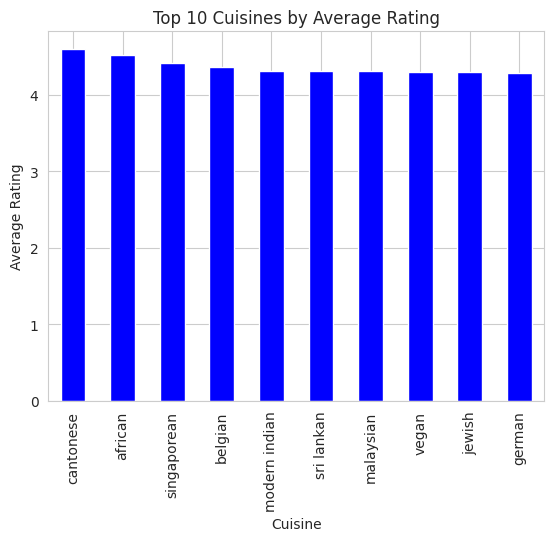

In [15]:
#Visualization Average rating vs Cuisine
avg_rating_cuisine.plot(kind='bar', color='blue')
plt.title("Top 10 Cuisines by Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Cuisine")
plt.show()

In [16]:
#Restaurant Count by Location
top_locations = df['location'].value_counts().head(10)
top_locations


,count
location,
btm,3930
koramangala 5th block,2319
hsr,2019
indiranagar,1845
jp nagar,1717
jayanagar,1643
whitefield,1578
marathahalli,1443
bannerghatta road,1235


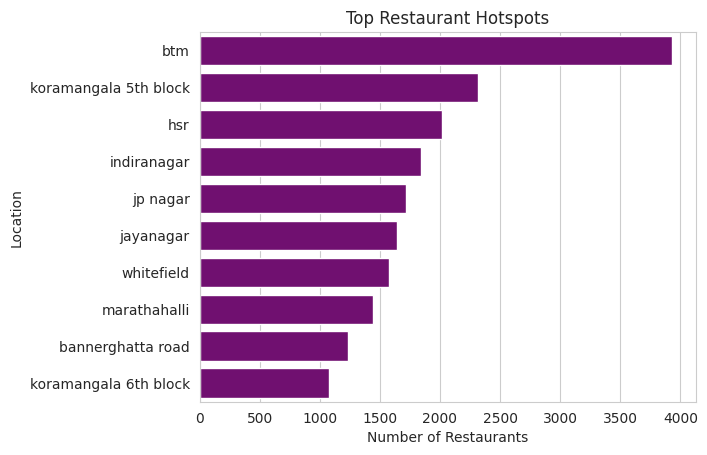

In [17]:
#Visualization Location vs No. of Restaurant
sns.barplot(x=top_locations.values, y=top_locations.index, color='purple')
plt.title("Top Restaurant Hotspots")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.show()


In [18]:
#Average Rating by Location
avg_rating_location = (
    df.groupby('location')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_rating_location


,rate
location,
lavelle road,4.142505
koramangala 3rd block,4.020419
st. marks road,4.017201
koramangala 5th block,4.005821
church street,3.992125
sankey road,3.965385
koramangala 4th block,3.918668
cunningham road,3.901053
residency road,3.863636


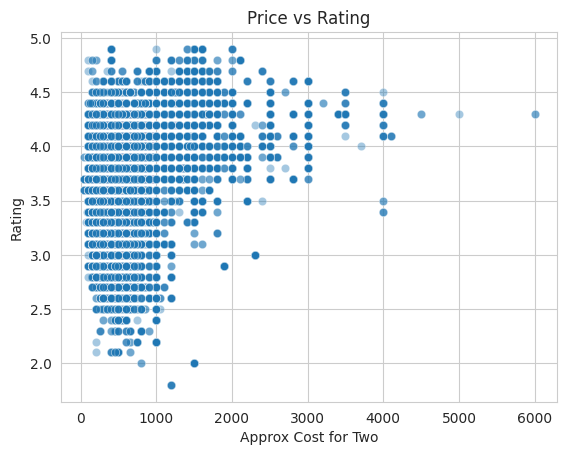

In [19]:
#Scatter Plot Price vs Rating Analysis
sns.scatterplot(
    data=df,
    x='approx_cost(for two people)',
    y='rate',
    alpha=0.4
)

plt.title("Price vs Rating")
plt.xlabel("Approx Cost for Two")
plt.ylabel("Rating")
plt.show()


In [20]:
df[['approx_cost(for two people)', 'rate']].corr()


,approx_cost(for two people),rate
approx_cost(for two people),1.000000,0.385156
rate,0.385156,1.000000


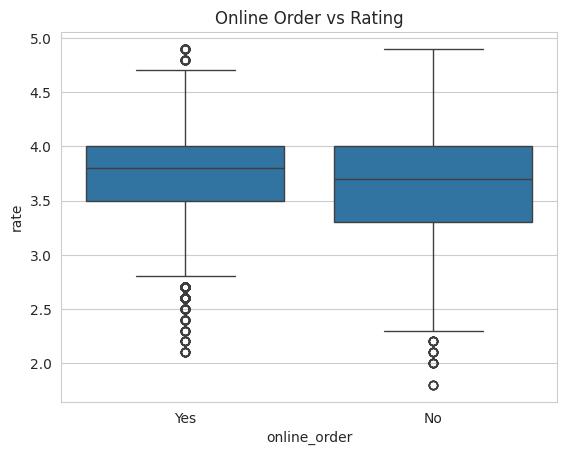

In [21]:
#Online Order & Table Booking Impact
sns.boxplot(x='online_order', y='rate', data=df)
plt.title("Online Order vs Rating")
plt.show()


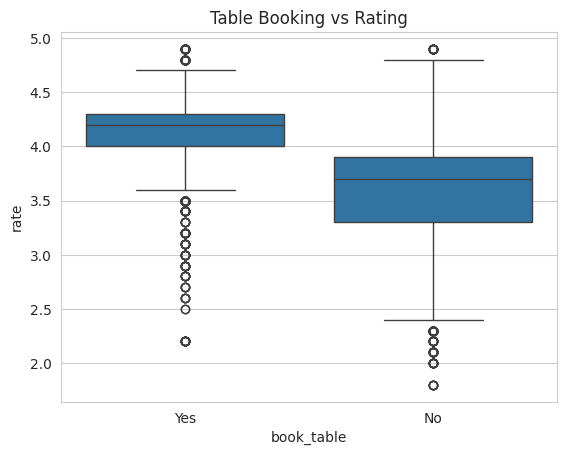

In [22]:
sns.boxplot(x='book_table', y='rate', data=df)
plt.title("Table Booking vs Rating")
plt.show()


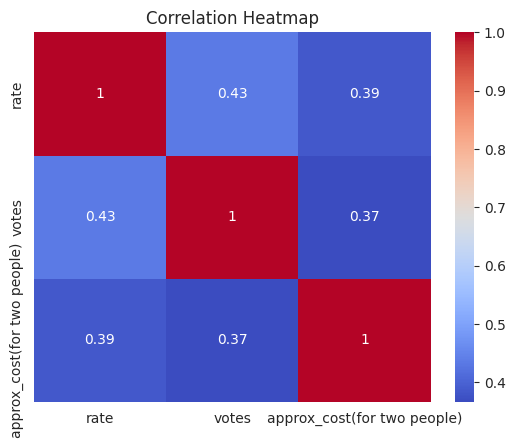

In [23]:
#Heatmap: Features vs Rating
feature_df = df[['rate', 'votes', 'approx_cost(for two people)']]

sns.heatmap(feature_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

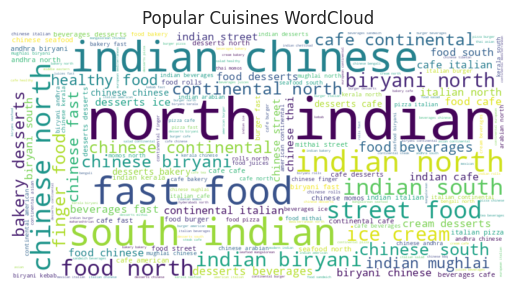

In [24]:
#WordCloud – Popular Cuisines
cuisine_text = " ".join(df['cuisines'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS
).generate(cuisine_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Cuisines WordCloud")
plt.show()


1. Smart Cuisine Promotion:
Promote high-rated cuisines region-wise to boost discovery.

2. Location-Based Recommendations:
Highlight restaurant hotspots using heatmap-based suggestions.

3. Value-for-Money Filters:
Recommend restaurants with best ratings under specific price ranges.

4. Feature Optimization for Partners:
Encourage restaurants to enable online ordering & table booking.

5. Content & Marketing Strategy:
Use cuisine/dish wordclouds for blogs like

  “Most Loved Dishes This Month”